### Paso 1.- Importar Librerias

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)

### Paso 2.- Cargar Dataset

In [22]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: /data/processed/coffee_quality_clean.csv
# La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../../data/processed/Juanma/coffee_quality_clean.csv')

print(f'✅ Datasets cargados correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Datasets cargados correctamente
📊 Dimensiones df: 1512 filas x 18 columnas


### Paso 3.- Preprocesamiento de Datos

#### Qué hacer con las siguientes columnas : Clean Cup, Color, Country of Origen, Harvest Year, Processing Method, Sweetness, Uniformity, Variety y altitud_limpia.

#### Mantengo altitud_limpia y Color y borro las demás.

In [23]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['Country of Origin', 'Harvest Year', 'Variety', 'Processing Method', 'Uniformity', 'Clean Cup', 'Sweetness'], axis=1)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Acidity               1512 non-null   float64
 1   Aftertaste            1512 non-null   float64
 2   Aroma                 1512 non-null   float64
 3   Balance               1512 non-null   float64
 4   Body                  1512 non-null   float64
 5   Category One Defects  1512 non-null   int64  
 6   Category Two Defects  1512 non-null   int64  
 7   Color                 1246 non-null   object 
 8   Flavor                1512 non-null   float64
 9   altitud_limpia        1252 non-null   float64
 10  Specialty             1512 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 130.1+ KB


### Que hacer con las columnas Altitude y Color

In [25]:
df.isna().sum()

Acidity                   0
Aftertaste                0
Aroma                     0
Balance                   0
Body                      0
Category One Defects      0
Category Two Defects      0
Color                   266
Flavor                    0
altitud_limpia          260
Specialty                 0
dtype: int64

#### Tratamiento de Color con MODA y one-hot encoding

In [26]:
# Estudio de nulos de Color
df['Color'].isna().sum()

np.int64(266)

In [27]:
# Rellenar los NaN con la moda

# Calcular la moda y rellenar NaN
moda = df['Color'].mode()[0]
print(moda)

df['Color'] = df['Color'].fillna(moda)

Green


In [9]:
# Usar one hot encoding
# Aplicar get_dummies
df = pd.get_dummies(df, columns=['Color'])
df.head(3)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Flavor,altitud_limpia,Specialty,Color_Blue-Green,Color_Bluish-Green,Color_Brown,Color_Green,Color_Yellow,Color_Yellow Green
0,8.75,8.67,8.67,8.42,8.50,0,0,8.83,2075.0,Specialty,False,False,False,True,False,False
1,8.58,8.50,8.75,8.42,8.42,0,1,8.67,2075.0,Specialty,False,False,False,True,False,False
2,8.42,8.42,8.42,8.42,8.33,0,0,8.50,1700.0,Specialty,False,False,False,True,False,False


In [29]:
df.shape

(1512, 16)

#### Tratamiento de Altitude

<Axes: >

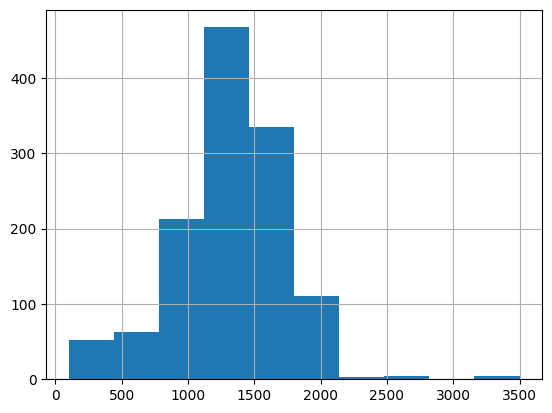

In [30]:
# Ver como es la distribución de la variable altitud_limpia
df['altitud_limpia'].hist()

In [31]:
# Rellenar los NaN con la media

# Calcular la moda y rellenar NaN
media = df['altitud_limpia'].mean()
print(media)

df['altitud_limpia'] = df['altitud_limpia'].fillna(media)

1320.2151552715657


<Axes: >

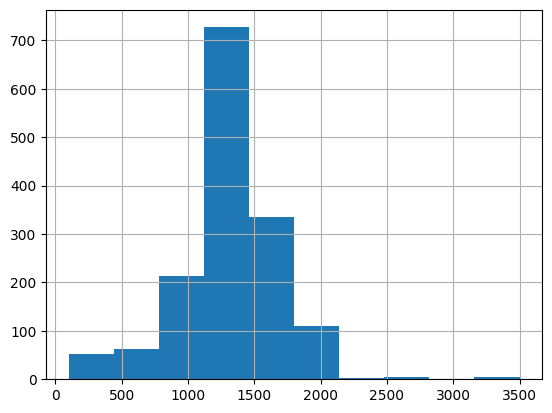

In [32]:
# Comprobar finalmente como es la distribución de la variable altitud_limpia
df['altitud_limpia'].hist()

In [33]:
df.sample(8)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Flavor,altitud_limpia,Specialty,Color_Blue-Green,Color_Bluish-Green,Color_Brown,Color_Green,Color_Yellow,Color_Yellow Green
636,7.67,7.42,7.75,7.50,7.42,0,0,7.33,800.000000,Specialty,False,False,False,True,False,False
1295,6.92,6.83,6.92,6.92,7.42,0,1,7.00,1000.000000,No Specialty,False,False,False,True,False,False
1370,7.67,7.67,8.08,7.75,7.67,0,2,7.83,1250.000000,Specialty,False,False,False,True,False,False
1002,7.42,7.08,7.33,7.33,7.17,0,5,7.33,1525.000000,No Specialty,False,False,False,True,False,False
537,7.42,7.67,8.08,7.50,7.33,0,0,7.50,1600.000000,Specialty,False,True,False,False,False,False
579,7.67,7.42,7.42,7.50,7.50,0,1,7.58,1219.200000,Specialty,False,False,False,True,False,False
73,7.67,8.00,8.00,8.00,7.75,0,1,8.00,1250.000000,Specialty,True,False,False,False,False,False
529,7.75,7.42,7.50,7.50,8.17,0,0,7.25,1320.215155,Specialty,False,False,False,True,False,False


#### Convertir la columna Specialty en 1 y 0

In [34]:
df['Specialty'] = df['Specialty'].map({'Specialty': 1, 'No Specialty': 0})
df.sample(4)

,Acidity,Aftertaste,Aroma,Balance,Body,Category One Defects,Category Two Defects,Flavor,altitud_limpia,Specialty,Color_Blue-Green,Color_Bluish-Green,Color_Brown,Color_Green,Color_Yellow,Color_Yellow Green
883,7.33,7.33,7.50,7.33,7.33,0,4,7.67,1752.600000,0,False,False,False,True,False,False
669,7.75,7.33,7.33,7.67,7.42,2,3,7.42,1320.215155,1,False,False,False,True,False,False
1391,7.83,7.67,7.67,7.67,7.75,0,2,7.83,1550.000000,1,False,False,False,True,False,False
494,7.67,7.58,7.50,7.50,7.58,0,5,7.58,894.000000,1,False,False,False,True,False,False


#### Dividir Datos en Entrenamiento y Test

In [35]:
# 1. Seleccionar características (X) y variable objetivo (y)
X = df.drop('Specialty', axis=1)
y = df['Specialty']

# 2. Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Paso 4.- Evaluar el modelo

### Función para evaluar cualquier modelo

#### Preparar las librerías

In [36]:
# Para cross_val_score y StratifiedKFold
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Para precision_score, recall_score y f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [37]:
# ─── Función para evaluar cualquier modelo ────────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    """
    Entrena el modelo, predice en test y devuelve un diccionario con todas las métricas.
    También hace validación cruzada para ver si el modelo es estable.
    """
    # Entrenar
    modelo.fit(X_tr, y_tr)
    
    # Predecir en test
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]  # probabilidad de la clase positiva (Specialty)
    
    # Validación cruzada con F1 (más fiable con dataset pequeño y desbalanceado)
    cv_scores = cross_val_score(
        modelo, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='f1'
    )
    
    return {
        'Modelo'     : nombre,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'Precision'  : precision_score(y_te, y_pred),
        'Recall'     : recall_score(y_te, y_pred),
        'F1'         : f1_score(y_te, y_pred),
        'ROC-AUC'    : roc_auc_score(y_te, y_prob),
        'CV F1 Media': cv_scores.mean(),
        'CV F1 Std'  : cv_scores.std(),
        'modelo_obj' : modelo
    }

print('✅ Función de evaluación lista')

✅ Función de evaluación lista


#### Evaluar modelos

#### Evaluar modelo Arbol de Decisión

In [38]:
# Evaluar Arbol de decision
clf = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
res_arbol = evaluar_modelo('Arbol de Decisión', clf, X_train, X_test, y_train, y_test)

print('📊 Arbol de Decisión:')
# Esto imprime las variables de return
for k, v in res_arbol.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')

📊 Arbol de Decisión:
  Accuracy: 0.8944
  Precision: 0.8721
  Recall: 0.9375
  F1: 0.9036
  ROC-AUC: 0.9408
  CV F1 Media: 0.9118
  CV F1 Std: 0.0145


#### Evaluar modelo XGBClassifier

#### Compruebo cuales son los mejores hiperparámetros para el modelo XGBClassifier

In [39]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(),
    param_grid=param_grid,
    cv=5, # Validación cruzada
    scoring='accuracy'
)

# Entrenar pasando el DataFrame de Pandas
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [40]:
# Evaluar XGBoost (Ensemble)
model = xgb.XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
res_xgboost = evaluar_modelo('XGBoost', model, X_train, X_test, y_train, y_test)

print('📊 XGBoost:')
# Esto imprime las variables de return
for k, v in res_xgboost.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')

📊 XGBoost:
  Accuracy: 0.9340
  Precision: 0.9167
  Recall: 0.9625
  F1: 0.9390
  ROC-AUC: 0.9701
  CV F1 Media: 0.9310
  CV F1 Std: 0.0210


#### Explicación de los datos optenidos con el mejor modelo XGBClassifier

Primero, contexto rápido: XGBoost es un modelo de machine learning muy potente que se usa mucho para clasificación (por ejemplo: “fraude / no fraude”, “enfermo / sano”, etc.).
Las métricas que muestras sirven para evaluar qué tan bien está funcionando el modelo.

1️⃣ Accuracy: 0.9340 (93.40%)

Qué es:
Es el porcentaje total de predicciones correctas.

Cómo se interpreta:
De cada 100 casos, el modelo acierta aproximadamente 93.

Importante:
Puede ser engañosa si las clases están desbalanceadas (por ejemplo, 95% “no fraude” y 5% “fraude”).

2️⃣ Precision: 0.9167 (91.67%)

Qué mide:
De todos los casos que el modelo dijo que eran positivos, ¿cuántos realmente lo eran?

Ejemplo:
Si el modelo detecta 100 fraudes, aproximadamente 92 realmente son fraude y 8 no lo eran.

Cuándo es importante:
Cuando los falsos positivos son costosos.
Ejemplo: marcar a alguien como fraude cuando no lo es.

3️⃣ Recall: 0.9625 (96.25%)

Qué mide:
De todos los positivos reales, ¿cuántos logró detectar el modelo?

Ejemplo:
Si hay 100 fraudes reales, detecta aproximadamente 96.

Cuándo es importante:
Cuando perder un caso positivo es grave.
Ejemplo: no detectar una enfermedad.

👉 En tu modelo, el recall es más alto que la precision.
Eso significa que el modelo prefiere “detectar casi todos los positivos”, aunque cometa algunos falsos positivos.

4️⃣ F1 Score: 0.9390 (93.90%)

Qué es:
Es un promedio balanceado entre precision y recall.

Se usa cuando:

Te importan ambas métricas

Hay cierto desbalance en las clases

Tu F1 de 0.939 indica un equilibrio muy bueno entre:

No fallar positivos (recall alto)

No inventar demasiados positivos (precision alta)

5️⃣ ROC-AUC: 0.9700 (97%)

Qué mide:
La capacidad del modelo para distinguir entre clases.

Escala:

0.5 → modelo aleatorio

0.7 → aceptable

0.8 → bueno

0.9+ → excelente

Tu 0.97 es excelente.
Significa que el modelo separa muy bien las clases.

6️⃣ CV F1 Media: 0.9333

Esto viene de cross-validation (validación cruzada).

En lugar de entrenar una sola vez, el modelo se entrena varias veces con diferentes particiones de los datos.

La media del F1 fue 0.9333.

👉 Esto indica que el rendimiento es consistente y no depende solo de una partición específica.

7️⃣ CV F1 Std: 0.0192

Es la desviación estándar del F1 en la validación cruzada.

0.0192 es bajo.

👉 Esto significa que el modelo es estable.
No cambia mucho su rendimiento entre distintos subconjuntos de datos.

📌 Resumen general

Tu modelo XGBoost:

Tiene muy buen rendimiento general

Detecta casi todos los positivos (recall muy alto)

Mantiene pocos falsos positivos (precision alta)

Es estable (baja desviación en CV)

Tiene excelente capacidad de separación (ROC-AUC 0.97)

En términos simples:
👉 Es un modelo fuerte, bien balanceado y consistente.

#### Guardar el modelo entrenado

In [ ]:
import joblib

# --- 3. Guardar el modelo y los datos de entrenamiento---
# Se recomienda usar joblib para modelos scikit-learn
joblib.dump(model, '../../models/Juanma/model.pkl')
print("Modelo guardado como 'model.pkl'")

# Encoders de categóricas (necesario para transformar datos nuevos en la app)
#joblib.dump(encoders, f'../../models/Jonathan/encoders.pkl')

# Lista de columnas en el orden exacto del entrenamiento
joblib.dump(list(X.columns), f'../../models/Juanma/feature_names.pkl')

joblib.dump(X_train, '../../models/Juanma/X_train.pkl')
joblib.dump(X_test,  '../../models/Juanma/X_test.pkl')
joblib.dump(y_train, '../../models/Juanma/y_train.pkl')
joblib.dump(y_test,  '../../models/Juanma/y_test.pkl')
print("Resto modelos guardados como '.pkl'")

Modelo guardado como 'modelo_XGBClassifier.pkl'
Resto modelos guardados como '.pkl'


In [42]:
import xgboost as xgb
import pandas as pd

# Obtener los pesos
importances = model.feature_importances_

# Crear un DataFrame para mejor visualización
feature_names = X_train.columns # si usas pandas
feature_imp_df = pd.DataFrame({'Característica': feature_names, 'Peso': importances})
feature_imp_df = feature_imp_df.sort_values(by='Peso', ascending=False)

print(feature_imp_df)

          Característica      Peso
7                 Flavor  0.394950
3                Balance  0.258578
1             Aftertaste  0.125463
4                   Body  0.061705
0                Acidity  0.058084
2                  Aroma  0.056263
12           Color_Green  0.017905
6   Category Two Defects  0.010306
8         altitud_limpia  0.010092
9       Color_Blue-Green  0.006653
5   Category One Defects  0.000000
10    Color_Bluish-Green  0.000000
11           Color_Brown  0.000000
13          Color_Yellow  0.000000
14    Color_Yellow Green  0.000000


<Figure size 1000x800 with 0 Axes>

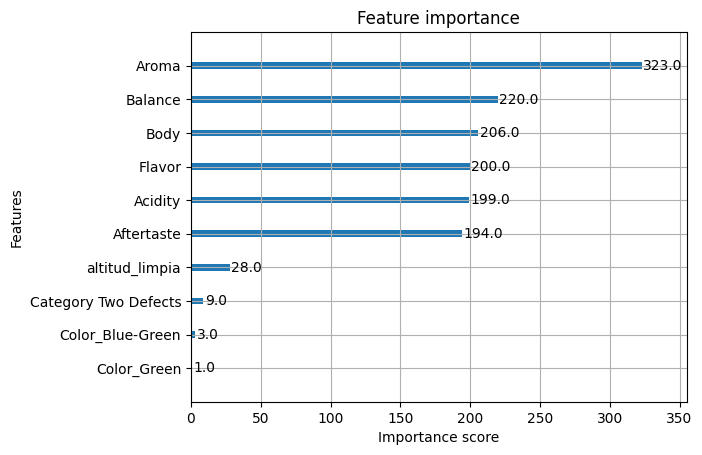

In [43]:
import matplotlib.pyplot as plt

# 3. Graficar pesos (Importancia por peso/frecuencia)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='weight') # 'weight' es el default
plt.show()

<Figure size 1000x800 with 0 Axes>

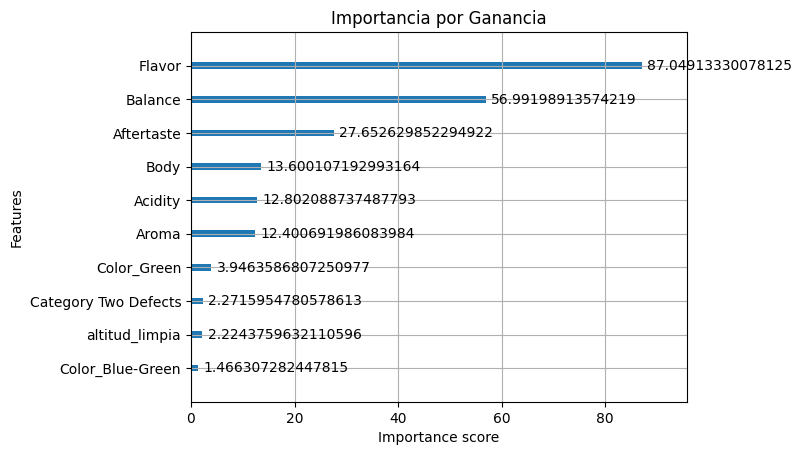

In [44]:
# Graficar por ganancia (cuánto mejora el modelo)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='gain', title='Importancia por Ganancia')
plt.show()